# Running parameter estimation

In this short example we'll show how to run parameter estimation with `pyringdown` models using `nessai`. We'll use some mock data for this.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyringdown.inference.likelihood import FDLikelihood
from pyringdown.waveform.interface import FDWaveform, TDWaveform
from pyringdown.waveform.fd import small_angle as fd_small_angle  # for the analysis
from pyringdown.waveform.td import small_angle  # for the injection

from pyringdown.inference.model import NessaiModel
from nessai.flowsampler import FlowSampler
from nessai.utils import configure_logger

import jax
jax.config.update("jax_enable_x64", True)

First, let's make some mock data to fit.

In [2]:
dt = 1e-3  # cadence
T = 2  # duration
sigma = 1e-2 # noise level

wf_td = TDWaveform(small_angle, dt=dt, T=T)

wf_td.parameters

['A', 'gamma', 'f_N', 'phi0']

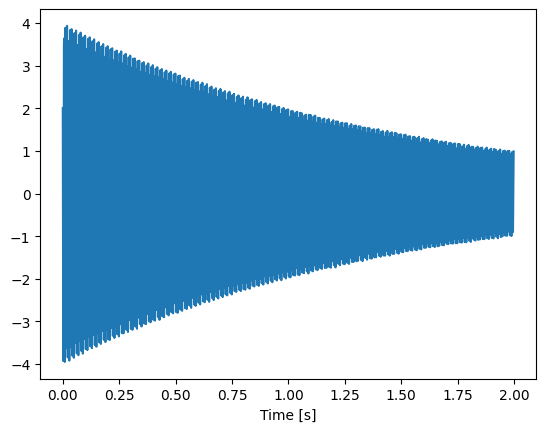

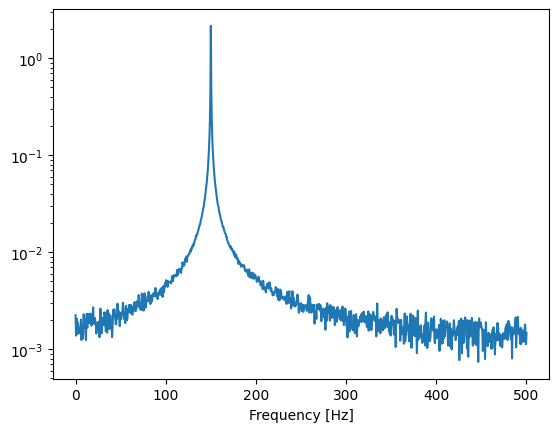

In [3]:

# injection parameters
inj_pars = {
    "A" : 4,
    "gamma" : 0.7,
    "f_N" : 150,
    "phi0" : np.pi/3,
}

signal = wf_td.get_td_waveform(inj_pars)

data = signal + sigma * np.random.normal(size=wf_td.Nt)

plt.plot(wf_td.t, data)
plt.xlabel("Time [s]")
plt.show()

# convert to frequency domain
fr = np.fft.rfftfreq(wf_td.Nt, dt)
data_fd = np.fft.rfft(data) * dt
plt.semilogy(fr, np.abs(data_fd))
plt.xlabel("Frequency [Hz]")
plt.show()

Now, let's set up our analysis waveform and configure `nessai` (see the `nessai` documentation for more help with the latter.). For the frequency domain waveforms, we can set a minimum and maximum frequency to save computational cost.

We must also choose bounds for our analysis.

In [4]:
output = "./outdir/mock-data-example/"
logger = configure_logger(output=output)

wf_fd = FDWaveform(fd_small_angle, dt=dt, T=T, df=1/T, f_min=140, f_max=160)

data = sigma * np.random.normal(size=wf_td.Nt)
data = data + wf_td.get_td_waveform(inj_pars)

fd_like = FDLikelihood(
    wf_fd, 
    td_data=data, 
    estimate_noise=True,
)

bounds = dict(
    A = [3.5, 4.5],
    gamma = [0.5, 0.9],
    f_N = [149.5, 150.5],
    phi0 = [0, 2*np.pi],
    noise_psd = [1e-8, 1e-4]  # noise PSD prior bounds. Check the periodogram for a reasonable guess.
)

model = NessaiModel(fd_like, bounds)


09-28 23:37 nessai INFO    : Running Nessai version 0.15.0


In [5]:
# The FlowSampler object is used to managed the sampling. Keyword arguments
# are passed to the nested sampling.
fs = FlowSampler(model, output=output, resume=False, seed=1729, nlive=1000)

# And go!
fs.run()

09-28 23:37 nessai INFO    : pool and n_pool are none, no multiprocessing pool
09-28 23:37 nessai INFO    : Initialising nested sampler
09-28 23:37 nessai WARNING : Multiprocessing pool has already been configured.
/Users/c.chapman-bird@bham.ac.uk/miniconda3/envs/jax-pyringdown/lib/python3.11/site-packages/nessai/gw/__init__.py:12: FutureWarning: The `nessai.gw` module will be deprecated in the next release in favour of the nessai-gw package. This packages provides the same functionality as`nessai.gw` via the plugin interface.For more details, see: https://github.com/mj-will/nessai-gw
  warnings.warn(
09-28 23:37 nessai INFO    : Passing kwargs to FlowProposal: {'poolsize': 1000}
09-28 23:37 nessai INFO    : No reparameterisations provided, using default reparameterisations included in FlowProposal
09-28 23:37 nessai INFO    : Adding reparameterisations from: {}
09-28 23:37 nessai INFO    : Assuming fallback reparameterisation (ScaleAndShift) for ['noise_psd', 'f_N', 'phi0', 'gamma', '

In [6]:
from nessai.plot import corner_plot
import os

truths = inj_pars.copy()
truths['noise_psd'] = sigma**2 * dt * 4

corner_plot(
    fs.posterior_samples,
    truths=truths,
    exclude=['logP','logL','it'],  # additional nessai outputs, excluded for corner plot
    filename=os.path.join(output, "corner.pdf")
)

Finally, let's check out the residual compared to the injection:

In [7]:
best_fit_template = wf_td.get_td_waveform(
    {nm: fs.posterior_samples[nm].mean() for nm in wf_td.parameters}
) 
resid = data - best_fit_template

(0.0, 0.5)

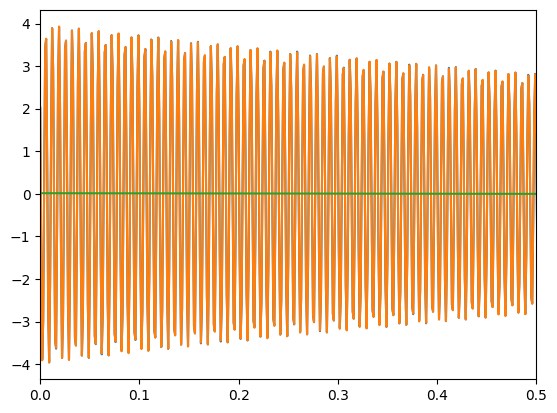

In [8]:
plt.plot(wf_td.t, data)
plt.plot(wf_td.t, best_fit_template)
plt.plot(resid)
plt.xlim(0, 0.5)

From the periodogram, we can see that the residual closely matches the original noise.

(140, 160)

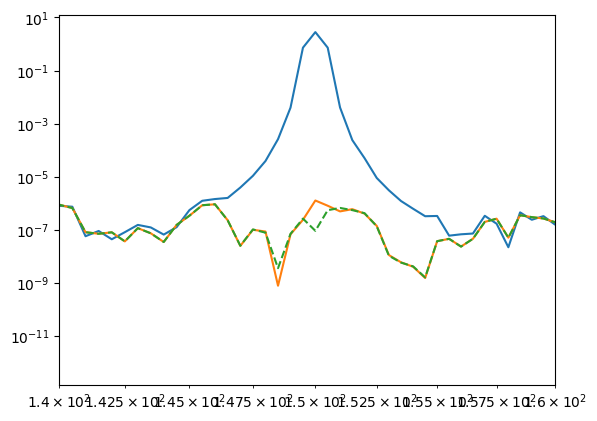

In [9]:
from scipy.signal import welch

welch_out = welch(data, fs=1/dt, nperseg=len(data)//1,)
welch_resid = welch(resid, fs=1/dt, nperseg=len(data)//1,)
welch_noise = welch(data - signal, fs=1/dt, nperseg=len(data)//1,)
plt.loglog(*welch_out)
plt.loglog(*welch_resid)
plt.loglog(*welch_noise, ls='--')
plt.xlim(140, 160)

# Fitting a double-ringdown signal

In future, helper functions will be designed to generate arbitrary numbers of sinusoids.

In [25]:
from pyringdown.waveform.fd import double_small_angle as fd_double_small_angle
from pyringdown.waveform.td import double_small_angle

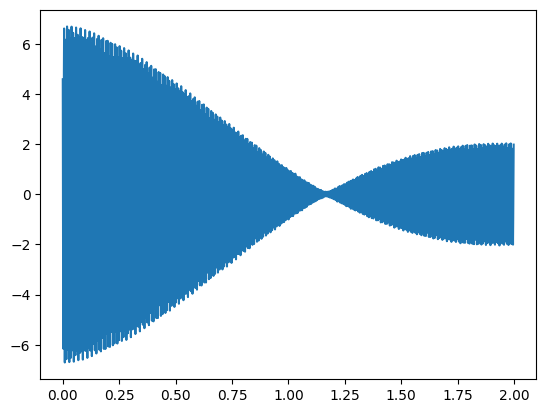

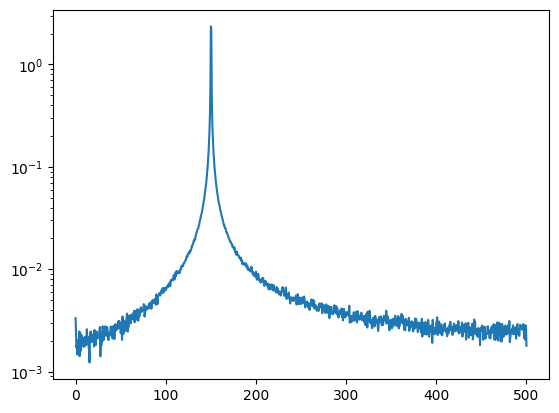

In [26]:
wf_td_2 = TDWaveform(double_small_angle, dt=dt, T=T)

inj_pars_2 = {
    "A_1" : 4,
    "gamma_1" : 0.7,
    "f_N_1" : 150,
    "phi0_1" : np.pi/3,
    "A_2" : 3,
    "gamma_2" : 0.5,
    "f_N_2" : 150.5,
    "phi0_2" : np.pi/6,
}

signal_2 = wf_td_2.get_td_waveform(inj_pars_2)
data_2 = signal_2 + sigma * np.random.normal(size=wf_td_2.Nt)
plt.plot(wf_td_2.t, data_2)
plt.show()

# convert to frequency domain
fr = np.fft.rfftfreq(wf_td_2.Nt, dt)
data_fd_2 = np.fft.rfft(data_2) * dt
plt.semilogy(fr, np.abs(data_fd_2))
plt.show()

Strong beating! We can fit this similarly to the 1-D case. Note the carefully tuned priors to avoid label-switching degeneracy: if this is nos possible, try defining a wrapper for the waveform model that works in terms of some residual parameter.

In [27]:
output = "./outdir/mock-data-2-example/"
logger = configure_logger(output=output)

wf_fd_2 = FDWaveform(fd_double_small_angle, dt=dt, T=T, df=1/T, f_min=140, f_max=160)

fd_like = FDLikelihood(
    wf_fd_2, 
    td_data=data_2, 
    estimate_noise=True,
)

bounds = dict(
    A_1= [3.5, 4.5],
    gamma_1 = [0.5, 0.9],
    f_N_1 = [149.75, 150.25],
    phi0_1 = [0, 2*np.pi],
    A_2= [2.5, 3.5],
    gamma_2 = [0.3, 0.7],
    f_N_2 = [150.25, 150.75],
    phi0_2 = [0, 2*np.pi],
    noise_psd = [1e-8, 1e-4]  # noise PSD prior bounds. Check the periodogram for a reasonable guess.
)

model = NessaiModel(fd_like, bounds)

09-28 23:45 nessai INFO    : Running Nessai version 0.15.0


In [28]:
# The FlowSampler object is used to managed the sampling. Keyword arguments
# are passed to the nested sampling.
fs = FlowSampler(model, output=output, resume=False, seed=1729, nlive=1000)

# And go!
fs.run()

09-28 23:45 nessai INFO    : pool and n_pool are none, no multiprocessing pool
09-28 23:45 nessai INFO    : Initialising nested sampler
09-28 23:45 nessai WARNING : Multiprocessing pool has already been configured.
09-28 23:45 nessai INFO    : Passing kwargs to FlowProposal: {'poolsize': 1000}
09-28 23:45 nessai INFO    : No reparameterisations provided, using default reparameterisations included in FlowProposal
09-28 23:45 nessai INFO    : Adding reparameterisations from: {}
09-28 23:45 nessai INFO    : Assuming fallback reparameterisation (ScaleAndShift) for ['gamma_2', 'A_1', 'gamma_1', 'f_N_1', 'noise_psd', 'f_N_2', 'A_2', 'phi0_2', 'phi0_1'] with kwargs: {'estimate_scale': True, 'estimate_shift': True, 'prior_bounds': {'gamma_2': array([0.3, 0.7]), 'A_1': array([3.5, 4.5]), 'gamma_1': array([0.5, 0.9]), 'f_N_1': array([149.75, 150.25]), 'noise_psd': array([1.e-08, 1.e-04]), 'f_N_2': array([150.25, 150.75]), 'A_2': array([2.5, 3.5]), 'phi0_2': array([0.        , 6.28318531]), 'phi0

In [29]:
from nessai.plot import corner_plot
import os

truths = inj_pars_2.copy()
truths['noise_psd'] = sigma**2 * dt * 4

corner_plot(
    fs.posterior_samples,
    truths=truths,
    exclude=['logP','logL','it'],  # additional nessai outputs, excluded for corner plot
    filename=os.path.join(output, "corner.pdf")
)

(0.0, 0.5)

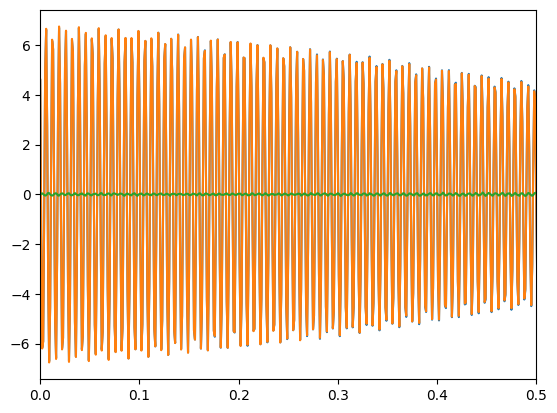

In [32]:
best_fit_template = wf_td_2.get_td_waveform(
    {nm: fs.posterior_samples[nm].mean() for nm in wf_td_2.parameters}
) 
resid = data_2 - best_fit_template

plt.plot(wf_td_2.t, data_2)
plt.plot(wf_td_2.t, best_fit_template)
plt.plot(wf_td_2.t, resid)
plt.xlim(0, 0.5)